### Cargar los paquetes

In [2]:
# Instalar y/o cargar todos los paquetes de una vez
if (!require("pacman")) {
  install.packages("pacman")
}
# Cargar paquetes necesarios para el análisis
pacman::p_load(
  factoextra,
  readr,
  FactoMineR,
  GGally,
  ggplot2,
  missMDA,
  corrplot,
  NbClust,
  cluster,
  fpc,
  dendextend,
  readxl,
  visdat,
  Hmisc,      # Load before tidyverse
  psych,      # Load before tidyverse
  tidyverse   # Loads dplyr last, ensuring its functions take precedence
)

Loading required package: pacman


### cargar la data

In [3]:
df <- read_excel(
  "C:\\Users\\user\\CO2-emsiones-tipo-combustible\\data\\raw\\emisiones_co2_sector_energetico_rd_2000_2022.xlsx"
)

str(df)

tibble [23 × 18] (S3: tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Bagazo de caña         : chr [1:23] "887.4920964106503" "896.0081500983246" "955.8754369729064" "930.9699942242929" ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : chr [1:23] "217.93571886222935" "318.9521536620553" "426.1185682949115" "281.1912566011516" ...
 $ Diesel                 : num [1:23] 6186 4719 4592 3284 3292 ...
 $ Fuel oil               : num [1:23] 2391 4332 4881 3359 1514 ...
 $ Gas licuado de petróleo: num [1:23] 1506 1448 1400 1317 1569 ...
 $ Gas natural            : chr [1:23] "-" "-" "-" "537.3374229656744" ...
 $ Gasolina               : num [1:23] 1878 2012 2076 1825 1631 ...
 $ Kerosene            

##### El conjunto original consta de 23 observaciones anuales (2000–2022) y 18 variables: el año, el total de emisiones y 16 categorías de combustible. “Total” es una función determinística de las demás columnas (su suma), por lo que se trató como variable suplementaria y no como predictor activo en los análisis posteriores.

## Análisis de los datos

### Visualización de los valores faltantes

In [4]:
conteo_guiones <- sapply(df, function(x) sum(x == "-", na.rm = TRUE))
conteo_guiones

                    Año                   Total                Asfaltos                   Avtur 
                      0                       0                       0                       0 
         Bagazo de caña          Carbón mineral                   Coque                  Diesel 
                      4                       0                       4                       0 
               Fuel oil Gas licuado de petróleo             Gas natural                Gasolina 
                      0                       0                       3                       0 
               Kerosene                    Leña             Lubricantes     Otros no energético 
                      5                       4                       0                       0 
        Otros primarias          Petróleo crudo 
                      4                       0 

Los valores representados con guion fueron tratados como datos faltantes para fines del análisis multivariante. Se ha tomado está decisión, dado que la fuente original no especifica de forma explícita si el guion representa ausencia de información, valor cero o no aplicación.

### convertir las variables a numéricas

In [5]:
df_num <- df |>
  mutate(across(everything(), ~ na_if(as.character(.), "-"))) |>
  mutate(across(everything(), as.numeric))

str(df_num)

tibble [23 × 18] (S3: tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Bagazo de caña         : num [1:23] 887 896 956 931 1029 ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : num [1:23] 218 319 426 281 862 ...
 $ Diesel                 : num [1:23] 6186 4719 4592 3284 3292 ...
 $ Fuel oil               : num [1:23] 2391 4332 4881 3359 1514 ...
 $ Gas licuado de petróleo: num [1:23] 1506 1448 1400 1317 1569 ...
 $ Gas natural            : num [1:23] NA NA NA 537 309 ...
 $ Gasolina               : num [1:23] 1878 2012 2076 1825 1631 ...
 $ Kerosene               : num [1:23] NA 0.275 NA NA NA ...
 $ Leña                   : num [1:23] 1739 1690 1702 1654 1633 ...
 $ Lubricantes            : n

Se procede a convertir todas las variables a numéricas, ya que los análisis a realizar usan algoritmos que son fundamentalmente modelos matemáticos y geométricos. No entienden texto, conceptos o categorías; solo entienden números, distancias y varianzas.

### valores faltantes

In [6]:
missing_summary <- df_num |>
  dplyr::summarize(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(
    everything(),
    names_to = "Variable",
    values_to = "Missing_Count"
  ) |>
  arrange(desc(Missing_Count))

missing_summary

# A tibble: 18 × 2
   Variable                Missing_Count
   <chr>                           <int>
 1 Kerosene                            5
 2 Bagazo de caña                      4
 3 Coque                               4
 4 Leña                                4
 5 Otros primarias                     4
 6 Gas natural                         3
 7 Año                                 0
 8 Total                               0
 9 Asfaltos                            0
10 Avtur                               0
11 Carbón mineral                      0
12 Diesel                              0
13 Fuel oil                            0
14 Gas licuado de petróleo             0
15 Gasolina                            0
16 Lubricantes                         0
17 Otros no energético                 0
18 Petróleo crudo                      0

In [7]:
missing_pct <- df_num |>
  dplyr::summarize(across(everything(), ~ sum(is.na(.)) / n() * 100)) |>
  pivot_longer(
    everything(),
    names_to = "Variable",
    values_to = "Missing_Pct"
  ) |>
  arrange(desc(Missing_Pct))

average_missing <- mean(missing_pct$Missing_Pct)
cat("Promedio de datos faltantes por variables:", average_missing, "%\n")

Promedio de datos faltantes por variables: 5.797101 %


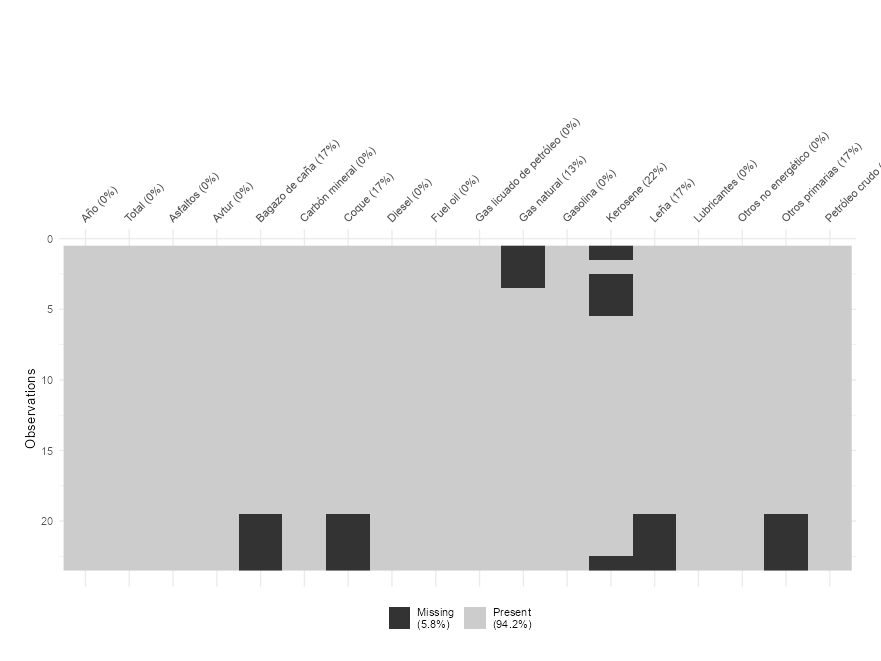

In [8]:
library(visdat)
grafico_miss <- vis_miss(df_num) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 0,
      vjust = 0
    ),
    plot.margin = margin(
      t = 80,
      r = 20,
      b = 20,
      l = 20
    )
  )

grafico_miss

El porcentaje promedio de datos faltantes por variable es de 5.80 %, concentrado en seis combustibles de uso marginal en la matriz energética (Kerosene, Bagazo de caña, Coque, Leña, Otros primarias y Gas natural). Ninguna variable supera el 22 % de datos faltantes (5 de 23 observaciones para Kerosene, el caso más extremo), por lo que se optó por imputación en lugar de eliminación de casos, dado además que n = 23 ya es una muestra reducida y cada año perdido representa información valiosa para el análisis de tendencia temporal.

### Imputación de datos faltantes

In [9]:
# Variables suplementarias
var_suplementarias <- c("Año", "Total")

# Variables activas: combustibles individuales
var_activas <- setdiff(names(df_num), var_suplementarias)

# Matriz activa
X <- df_num[, var_activas]

# Información suplementaria
info <- df_num[, var_suplementarias]

# Estimar número de componentes para imputación solo en combustibles
nb <- estim_ncpPCA(X, method = "Regularized")

# Imputar solo variables activas
X_imp <- imputePCA(X, ncp = nb$ncp)$completeObs

# Reconstruir base imputada
data_num_imputed <- bind_cols(
  info,
  as.data.frame(X_imp)
)

In [11]:
overall_missing_X <- sum(is.na(X)) / (nrow(X) * ncol(X)) * 100

cat("Datos faltantes en la matriz activa:", overall_missing_X, "%\n")

Datos faltantes en la matriz activa: 6.521739 %


La imputación se restringió a la matriz activa de 16 combustibles (6.52 % de celdas faltantes), excluyendo explícitamente Año y Total como variables suplementarias. Se empleó PCA regularizado (missMDA::imputePCA, con el número de componentes estimado mediante estim_ncpPCA) en lugar de imputación por media, porque preserva la estructura de correlación multivariante entre tipos de combustible — relevante dado que se esperan relaciones de sustitución/complementariedad entre fuentes energéticas (p. ej., el desplazamiento de fuel oil hacia gas natural).

In [ ]:
 library(readr)

 write_csv(
  data_num_imputed,
  "C:/Users/user/CO2-emsiones-tipo-combustible/data/processed/data_num_imputed.csv"
)